Preliminary analysis of football manager dataset

In [ ]:
import pandas as pd
import numpy as np
import os 
csv_path = os.path.join(os.getcwd(), "data","final","fbmandataset.csv")

df = pd.read_csv(csv_path)
print(f"Shape of the dataset: {df.shape}")
df.columns

Shape of the dataset: (159541, 89)


Index(['UID', 'Name', 'NationID', 'Born', 'Age', 'IntCaps', 'IntGoals',
       'U21Caps', 'U21Goals', 'Height', 'Weight', 'AerialAbility',
       'CommandOfArea', 'Communication', 'Eccentricity', 'Handling', 'Kicking',
       'OneOnOnes', 'Reflexes', 'RushingOut', 'TendencyToPunch', 'Throwing',
       'Corners', 'Crossing', 'Dribbling', 'Finishing', 'FirstTouch',
       'Freekicks', 'Heading', 'LongShots', 'Longthrows', 'Marking', 'Passing',
       'PenaltyTaking', 'Tackling', 'Technique', 'Aggression', 'Anticipation',
       'Bravery', 'Composure', 'Concentration', 'Vision', 'Decisions',
       'Determination', 'Flair', 'Leadership', 'OffTheBall', 'Positioning',
       'Teamwork', 'Workrate', 'Acceleration', 'Agility', 'Balance', 'Jumping',
       'LeftFoot', 'NaturalFitness', 'Pace', 'RightFoot', 'Stamina',
       'Strength', 'Consistency', 'Dirtiness', 'ImportantMatches',
       'InjuryProness', 'Versatility', 'Adaptability', 'Ambition', 'Loyalty',
       'Pressure', 'Professional',

In [6]:
df.head(5)

,UID,Name,NationID,Born,Age,IntCaps,IntGoals,U21Caps,U21Goals,Height,...,AttackingMidRight,DefenderCentral,DefenderLeft,DefenderRight,DefensiveMidfielder,MidfielderCentral,MidfielderLeft,MidfielderRight,WingBackLeft,WingBackRight
0,1000055,Wilfred Bamnjo,11,27-03-1980,36,0,0,0,0,178,...,1,1,1,1,20,11,1,1,1,1
1,1000331,Wang Wei,110,20-02-1982,34,0,0,0,0,188,...,1,1,1,1,1,1,1,1,1,1
2,1000334,Liu Yang,110,11-04-1982,34,0,0,0,0,183,...,1,1,1,1,20,1,1,1,1,1
3,1000337,Song Qi,110,07-04-1985,31,0,0,0,0,170,...,1,1,1,1,1,1,1,1,1,1
4,1000340,Chen Lei,110,20-01-1983,33,0,0,0,0,181,...,1,1,1,1,1,1,1,1,1,1


Running a quick check if posititons match the stats

In [9]:
"""
FM CSV - Positional Consistency Analysis
-----------------------------------------
For a random 1000-player sample, this script:
  1. Converts relevant columns to numpy arrays (vectorised)
  2. Finds each player's PRIMARY position (max value across positional columns)
  3. Checks whether the `Positioning` attribute is meaningful for that position
  4. Checks whether `PositionsDesc` actually mentions the detected primary position
"""

# ── CONFIG ────────────────────────────────────────────────────────────────────
SAMPLE_N   = 1000
RANDOM_SEED = 42

# Positional rating columns (the ones that hold FM position suitability 0-20)
POSITION_COLS = [
    "Goalkeeper",
    "Sweeper",
    "Striker",
    "AttackingMidCentral",
    "AttackingMidLeft",
    "AttackingMidRight",
    "DefenderCentral",
    "DefenderLeft",
    "DefenderRight",
    "DefensiveMidfielder",
    "MidfielderCentral",
    "MidfielderLeft",
    "MidfielderRight",
    "WingBackLeft",
    "WingBackRight",
]

# Human-readable labels aligned with POSITION_COLS
POSITION_LABELS = [
    "GK", "SW", "ST",
    "AMC", "AML", "AMR",
    "DC",  "DL",  "DR",
    "DM",  "MC",  "ML",  "MR",
    "WBL", "WBR",
]

# PositionsDesc keywords we expect for each position label
# (FM uses abbreviations like "GK", "ST", "AMC" etc. in that field)
POSITION_KEYWORDS = {
    "GK":  ["GK"],
    "SW":  ["SW"],
    "ST":  ["ST"],
    "AMC": ["AMC"],
    "AML": ["AML"],
    "AMR": ["AMR"],
    "DC":  ["DC", "CB"],
    "DL":  ["DL"],
    "DR":  ["DR"],
    "DM":  ["DM", "CDM"],
    "MC":  ["MC", "CM"],
    "ML":  ["ML"],
    "MR":  ["MR"],
    "WBL": ["WBL"],
    "WBR": ["WBR"],
}

# Positions where the FM 'Positioning' attribute has limited meaning
# (GK has their own positioning logic; Sweeper is edge-case)
LOW_RELEVANCE_POSITIONS = {"GK", "SW"}

# ── LOAD & SAMPLE ─────────────────────────────────────────────────────────────
print("Using loaded dataframe …")
sample = df.sample(n=min(SAMPLE_N, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)
print(f"  Sample size  : {sample.shape}\n")

# ── NUMPY ARRAYS ──────────────────────────────────────────────────────────────
# Positional suitability matrix  →  shape (N, 15)
pos_matrix = sample[POSITION_COLS].to_numpy(dtype=np.float32)

# Positioning attribute  →  shape (N,)
positioning_attr = sample["Positioning"].to_numpy(dtype=np.float32)

# PositionsDesc  →  object array of strings
positions_desc = sample["PositionsDesc"].fillna("").to_numpy(dtype=str)

# Player names for reporting
names = sample["Name"].to_numpy(dtype=str)

# ── VECTORISED PRIMARY POSITION DETECTION ─────────────────────────────────────
# For each player: index of the highest positional rating
primary_idx   = np.argmax(pos_matrix, axis=1)            # shape (N,)
primary_score = pos_matrix[np.arange(len(sample)), primary_idx]  # shape (N,)
primary_label = np.array(POSITION_LABELS)[primary_idx]   # shape (N,)

# ── POSITIONING ATTRIBUTE RELEVANCE CHECK (vectorised) ────────────────────────
# Flag: True when the player's primary pos is GK or SW (Positioning = less meaningful)
is_low_relevance = np.isin(primary_label, list(LOW_RELEVANCE_POSITIONS))  # shape (N,)

# Threshold: a GK with high Positioning (>12) is worth flagging
POSITIONING_HIGH_THRESHOLD = 12
positioning_flag = is_low_relevance & (positioning_attr > POSITIONING_HIGH_THRESHOLD)

# ── POSITIONSDESC CONSISTENCY CHECK (vectorised via np.frompyfunc) ────────────
def desc_matches(label: str, desc: str) -> bool:
    """Return True if PositionsDesc contains at least one expected keyword."""
    keywords = POSITION_KEYWORDS.get(label, [label])
    return any(kw in desc for kw in keywords)

_vec_match = np.frompyfunc(desc_matches, 2, 1)
desc_consistent = _vec_match(primary_label, positions_desc).astype(bool)  # shape (N,)

# ── SUMMARY STATISTICS ────────────────────────────────────────────────────────
print("=" * 60)
print("POSITIONAL DISTRIBUTION (primary position by max suitability)")
print("=" * 60)
unique_labels, counts = np.unique(primary_label, return_counts=True)
for lbl, cnt in sorted(zip(unique_labels, counts), key=lambda x: -x[1]):
    bar = "█" * (cnt // 5)
    print(f"  {lbl:5s}  {cnt:4d}  {bar}")

print(f"\n{'=' * 60}")
print("POSITIONING ATTRIBUTE RELEVANCE")
print(f"{'=' * 60}")
n_gk_sw = is_low_relevance.sum()
n_flagged = positioning_flag.sum()
print(f"  GK / SW players in sample     : {n_gk_sw}")
print(f"  GK/SW with Positioning > {POSITIONING_HIGH_THRESHOLD:2d}   : {n_flagged}  ← worth inspecting")

print(f"\n{'=' * 60}")
print("POSITIONSDESC CONSISTENCY")
print(f"{'=' * 60}")
n_consistent   = desc_consistent.sum()
n_inconsistent = (~desc_consistent).sum()
pct = 100 * n_consistent / len(sample)
print(f"  Consistent   : {n_consistent}  ({pct:.1f}%)")
print(f"  Inconsistent : {n_inconsistent}")

# ── DETAILED INSPECTION TABLES ────────────────────────────────────────────────
# Build a results DataFrame for easy inspection
results = pd.DataFrame({
    "Name":           names,
    "PrimaryPos":     primary_label,
    "PrimaryScore":   primary_score,
    "Positioning":    positioning_attr,
    "PositioningFlag": positioning_flag,
    "PositionsDesc":  positions_desc,
    "DescConsistent": desc_consistent,
})

print(f"\n{'=' * 60}")
print("SAMPLE: Flagged GK/SW with high Positioning attribute")
print(f"{'=' * 60}")
flagged = results[results["PositioningFlag"]]
if flagged.empty:
    print("  None found — good!")
else:
    print(flagged[["Name", "PrimaryPos", "PrimaryScore", "Positioning", "PositionsDesc"]].to_string(index=False))

print(f"\n{'=' * 60}")
print("SAMPLE: Players where PositionsDesc is INCONSISTENT (first 20)")
print(f"{'=' * 60}")
inconsistent = results[~results["DescConsistent"]].head(20)
if inconsistent.empty:
    print("  None found — good!")
else:
    print(inconsistent[["Name", "PrimaryPos", "PrimaryScore", "PositionsDesc"]].to_string(index=False))

# ── EXPORT ────────────────────────────────────────────────────────────────────
out_path = os.path.join(os.getcwd(), "data", "intermediate", "fm_positional_analysis_results.csv")
results.to_csv(out_path, index=False)
print(f"\n✓ Full results saved to: {out_path}")

Using loaded dataframe …
  Sample size  : (1000, 89)

POSITIONAL DISTRIBUTION (primary position by max suitability)
  ST      185  █████████████████████████████████████
  DC      168  █████████████████████████████████
  MC      115  ███████████████████████
  DR       90  ██████████████████
  GK       87  █████████████████
  AMC      69  █████████████
  DL       63  ████████████
  DM       61  ████████████
  AMR      59  ███████████
  AML      38  ███████
  ML       31  ██████
  MR       26  █████
  WBL       4  
  WBR       3  
  SW        1  

POSITIONING ATTRIBUTE RELEVANCE
  GK / SW players in sample     : 88
  GK/SW with Positioning > 12   : 9  ← worth inspecting

POSITIONSDESC CONSISTENCY
  Consistent   : 148  (14.8%)
  Inconsistent : 852

SAMPLE: Flagged GK/SW with high Positioning attribute
             Name PrimaryPos  PrimaryScore  Positioning PositionsDesc
     Victor Golas         GK          20.0         13.0           GK 
  Roberto Salcedo         GK          20.0         

In [10]:
# ── INSPECT FIRST 5 PLAYERS ──────────────────────────────────────────────────
print("=" * 80)
print("DETAILED INSPECTION: First 5 Players")
print("=" * 80)

# Create subset with first 5 players
subdf = results.head(5)

print(f"\nSubset shape: {subdf.shape}")
print(f"\nColumns in results DataFrame:\n{list(results.columns)}")

print("\n" + "=" * 80)
print("SUBSET DATA (first 5 players):")
print("=" * 80)
print(subdf.to_string(index=False))

print("\n" + "=" * 80)
print("COLUMN DETAILS: PrimaryScore, PositionsDesc, Positioning")
print("=" * 80)

for idx, row in subdf.iterrows():
    print(f"\n[Player {idx}] {row['Name']}")
    print(f"  PrimaryPos      : {row['PrimaryPos']}")
    print(f"  PrimaryScore    : {row['PrimaryScore']:.1f}  (column: 'PrimaryScore')")
    print(f"  Positioning     : {row['Positioning']:.1f}  (column: 'Positioning')")
    print(f"  PositionsDesc   : '{row['PositionsDesc']}'  (column: 'PositionsDesc')")
    print(f"  DescConsistent  : {row['DescConsistent']}")

print("\n" + "=" * 80)
print("COLUMN DTYPES:")
print("=" * 80)
print(subdf[["PrimaryScore", "PositionsDesc", "Positioning"]].dtypes)

DETAILED INSPECTION: First 5 Players

Subset shape: (5, 7)

Columns in results DataFrame:
['Name', 'PrimaryPos', 'PrimaryScore', 'Positioning', 'PositioningFlag', 'PositionsDesc', 'DescConsistent']

SUBSET DATA (first 5 players):
                Name PrimaryPos  PrimaryScore  Positioning  PositioningFlag PositionsDesc  DescConsistent
 Angelos Pechlivanis        AMC          20.0          3.0            False          AM C           False
Anestis Chatziliadis         DR          20.0          8.0            False        D/WB R           False
         Vasyl Kurko         MC          20.0          5.0            False           M C           False
         Kevin Doran         MR          20.0          3.0            False       M/AM RL           False
         Tomas Kosut         DC          20.0         13.0            False          D LC           False

COLUMN DETAILS: PrimaryScore, PositionsDesc, Positioning

[Player 0] Angelos Pechlivanis
  PrimaryPos      : AMC
  PrimaryScore    : 

In [13]:
#df = df.drop(columns=["PositionsDesc"])

print("PositionsDesc" in df.columns)

False


In [17]:
df.info()

describe_num = df.describe()
print(describe_num)

descr_obj = df.describe(include=['object'])      # categoricals
print(descr_obj)

<class 'pandas.DataFrame'>
RangeIndex: 159541 entries, 0 to 159540
Data columns (total 87 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   UID                  159541 non-null  int64
 1   Name                 159541 non-null  str  
 2   NationID             159541 non-null  int64
 3   Age                  159541 non-null  int64
 4   IntCaps              159541 non-null  int64
 5   IntGoals             159541 non-null  int64
 6   U21Caps              159541 non-null  int64
 7   U21Goals             159541 non-null  int64
 8   Height               159541 non-null  int64
 9   Weight               159541 non-null  int64
 10  AerialAbility        159541 non-null  int64
 11  CommandOfArea        159541 non-null  int64
 12  Communication        159541 non-null  int64
 13  Eccentricity         159541 non-null  int64
 14  Handling             159541 non-null  int64
 15  Kicking              159541 non-null  int64
 16  OneOnOnes    

/tmp/ipykernel_571575/3814432848.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  descr_obj = df.describe(include=['object'])      # categoricals


In [26]:
#df = df.drop(columns=["Born"])
df = df.drop(columns=["UID"], errors='ignore')  # safer drop with error handling
print("Born" in df.columns)
print("UID" in df.columns)

False
False


In [27]:
# ── DATA TYPE & KEY VARIABLE MANAGEMENT ───────────────────────────────────────
print("=" * 80)
print("DATA TYPE & KEY VARIABLE CONFIGURATION")
print("=" * 80)

# Convert NationID to categorical
print("\nConverting NationID to categorical…")
df["NationID"] = df["NationID"].astype("category")
print(f"  NationID dtype: {df['NationID'].dtype}")
print(f"  Unique nations: {df['NationID'].nunique()}")

# Mark Name as a key variable (keep but don't use in pipeline)
KEY_VARIABLES = ["Name"]
print(f"\nKey variables (kept but excluded from pipeline): {KEY_VARIABLES}")
print(f"  These will be retained for identification but not used in modeling")

# Show updated info
print("\n" + "=" * 80)
print("UPDATED DATAFRAME INFO:")
print("=" * 80)
print(df.info())

print(f"\nDataframe shape: {df.shape}")
print(f"Key variables: {KEY_VARIABLES}")
print(f"Categorical columns: {df.select_dtypes(include='category').columns.tolist()}")

DATA TYPE & KEY VARIABLE CONFIGURATION

Converting NationID to categorical…
  NationID dtype: category
  Unique nations: 213

Key variables (kept but excluded from pipeline): ['Name']
  These will be retained for identification but not used in modeling

UPDATED DATAFRAME INFO:
<class 'pandas.DataFrame'>
RangeIndex: 159541 entries, 0 to 159540
Data columns (total 86 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   Name                 159541 non-null  str     
 1   NationID             159541 non-null  category
 2   Age                  159541 non-null  int64   
 3   IntCaps              159541 non-null  int64   
 4   IntGoals             159541 non-null  int64   
 5   U21Caps              159541 non-null  int64   
 6   U21Goals             159541 non-null  int64   
 7   Height               159541 non-null  int64   
 8   Weight               159541 non-null  int64   
 9   AerialAbility        159541 non-null  int64  

In [28]:

out_path = os.path.join(os.getcwd(), "data", "intermediate", "preliminary_analysis.csv")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df.to_csv(out_path, index=False)
print(f"✓ Dataframe saved to: {out_path}")
print(f"  File exists: {os.path.exists(out_path)}")

✓ Dataframe saved to: /home/kondr/fm-research/data/intermediate/preliminary_analysis.csv
  File exists: True


In [ ]:
"""
FM Dataset — Batched Unsupervised ML Pipeline
==============================================
Notebook-safe. Designed to be gentle on RAM and CPU.

  KERNEL RESTART NOTE
    The thread-cap env vars below must be set before numpy/sklearn are
    imported for the first time.  In Jupyter, run this as the very first
    cell after a fresh kernel start, or the caps will have no effect on
    BLAS internals (the _cpu_limit() contexts still help for sklearn's
    own thread pools, but BLAS is initialised once at import time).

Structure
---------
  Config     — single dataclass, all knobs in one place
  Phase 1a   — StandardScaler.partial_fit over CSV chunks  (CSV pass 1)
  Phase 1b   — IncrementalPCA.partial_fit on scaled chunks (CSV pass 2)
  Phase 2    — transform full CSV → PCA coords on disk memmap (CSV pass 3)
  Phase 3    — MiniBatchKMeans sweep over PCA memmap
  Phase 4    — IsolationForest fit on sample, score to disk memmap
  Phase 5    — assemble results CSV

Memory notes
------------
  - CSV is streamed in chunks; the full feature table is never in RAM.
    (_count_rows and phase5_results each read the Name column in full —
    that is one lightweight column, not the feature table, but it is not
    strictly zero extra RAM.)
  - PCA output and anomaly scores live on disk as memmaps.
  - Each phase explicitly deletes its large objects and calls gc.collect().
  - sklearn upcasts float32 → float64 internally; batch_size formula
    accounts for this (peak ≈ 4× raw float64 chunk size).

Pipeline.partial_fit note
--------------------------
  sklearn.pipeline.Pipeline does NOT expose partial_fit, so Phase 1 is
  split into two explicit CSV passes (1a scaler, 1b PCA).  Once both are
  fitted, a Pipeline is assembled purely for the transform step in Phase 2
  — Pipeline.transform works correctly on already-fitted steps.
"""

# ── Thread caps — set BEFORE numpy/sklearn import ──────────────────────────────
import os
import warnings

_N_CPU = "2"   # raise to 4 if you have headroom; keep at 2 to stay responsive
for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
             "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_var, _N_CPU)

import gc
import math
import time
from contextlib import contextmanager
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from numpy.lib.format import open_memmap
from sklearn.decomposition import IncrementalPCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from threadpoolctl import threadpool_limits as _tpl
    def _cpu_limit(n: int):
        return _tpl(limits=n)
except ImportError:
    @contextmanager
    def _cpu_limit(n: int):
        yield


# ── CONFIG ────────────────────────────────────────────────────────────────────

@dataclass
class Config:
    # Paths
    csv_path:   str = os.path.join(os.getcwd(), "data", "intermediate", "preliminary_analysis.csv")
    output_dir: str = os.path.join(os.getcwd(), "data", "intermediate")

    # Identifier column: carried through to results but never fed to the model
    id_cols: list = field(default_factory=lambda: ["Name"])

    # Columns excluded from the model.
    # NationID is categorical; its integer codes imply a numerical distance
    # between nations that doesn't exist, so we drop it rather than encode it.
    drop_cols: list = field(default_factory=lambda: ["NationID"])

    # PCA
    n_components: int = 25

    # Clustering
    k_range:       range = field(default_factory=lambda: range(3, 12))
    kmeans_n_init: int   = 3     # 1 is fragile; 3 is a safe minimum

    # Anomaly detection
    contamination:        float = 0.05
    iforest_fit_rows:     int   = 20_000
    iforest_n_estimators: int   = 100

    # Silhouette subsample — 2 000 is gentler on CPU than 5 000;
    # the k estimate is slightly noisier but still directionally correct.
    silhouette_n_rows: int = 2_000

    # Memory: target peak RAM per batch.
    # Peak ≈ 4× raw float64 chunk (raw + scaled copy + PCA buffers).
    # 48 MB → very safe; raise to 96–128 MB if you want faster throughput.
    target_ram_mb: int = 48

    # CPU thread cap
    n_cpu: int = 2


CFG = Config()


# ── INTERNAL HELPERS ──────────────────────────────────────────────────────────

def _batch_size(n_cols: int, cfg: Config) -> int:
    """
    Conservative batch size.
    sklearn StandardScaler.transform and IncrementalPCA.partial_fit both
    operate in float64 internally regardless of input dtype.
    Peak per batch ≈ 4× raw float64 chunk; we honour that here.
    """
    bytes_per_row = n_cols * 8   # float64
    peak_factor   = 4.0
    batch = int((cfg.target_ram_mb * 1024 ** 2) / (bytes_per_row * peak_factor))
    batch = max(batch, cfg.n_components + 1, 500)
    return int(math.ceil(batch / 500) * 500)


def _feature_cols(cfg: Config) -> list[str]:
    """Detect numeric feature columns from a small CSV preview."""
    exclude = set(cfg.id_cols) | set(cfg.drop_cols)
    preview = pd.read_csv(cfg.csv_path, nrows=100, low_memory=False)
    cols = [
        c for c in preview.columns
        if c not in exclude and pd.api.types.is_numeric_dtype(preview[c])
    ]
    skipped = [c for c in preview.columns if c not in exclude and c not in cols]
    if skipped:
        warnings.warn(f"Skipping non-numeric columns: {skipped}")
    return cols


def _count_rows(cfg: Config) -> int:
    """
    Count rows by loading only the Name column.
    Lighter than loading the full feature table, but not zero — it reads
    one column (~1.2 MB for 159 k strings) into RAM.
    """
    return pd.read_csv(cfg.csv_path, usecols=[cfg.id_cols[0]], low_memory=False).shape[0]


def _csv_chunks(cfg: Config, feature_cols: list[str], batch_size: int):
    """Stream (batch_index, float32 array) from CSV without loading it all."""
    reader = pd.read_csv(
        cfg.csv_path,
        usecols=feature_cols,
        chunksize=batch_size,
        low_memory=False,
    )
    for i, chunk in enumerate(reader):
        yield i, chunk.to_numpy(dtype=np.float32, copy=False)


def _array_chunks(arr: np.ndarray, batch_size: int):
    """Yield (start, stop, slice) over any array or memmap."""
    for start in range(0, len(arr), batch_size):
        stop = min(start + batch_size, len(arr))
        yield start, stop, arr[start:stop]


def _safe_silhouette(coords: np.ndarray, labels: np.ndarray) -> float:
    n_unique = len(np.unique(labels))
    if n_unique < 2 or n_unique >= len(coords):
        return -1.0
    return float(silhouette_score(coords, labels, metric="euclidean"))


def _progress(i: int, n: int, label: str = "batch"):
    print(f"  {label} {i+1}/{n}", end="\r", flush=True)


def _clear():
    print(" " * 60, end="\r")


# ── PHASE 1a — fit StandardScaler (CSV pass 1) ────────────────────────────────

def phase1a_fit_scaler(cfg: Config, feature_cols: list[str],
                       batch_size: int, n_batches: int) -> StandardScaler:
    """
    Streams every batch through StandardScaler.partial_fit to learn the
    global mean and variance without loading the full dataset.
    """
    print("Phase 1a — StandardScaler.partial_fit (CSV pass 1) …")
    scaler = StandardScaler()
    with _cpu_limit(cfg.n_cpu):
        for i, batch in _csv_chunks(cfg, feature_cols, batch_size):
            scaler.partial_fit(batch)
            _progress(i, n_batches)
    _clear()
    print("  Scaler fitted.\n")
    return scaler


# ── PHASE 1b — fit IncrementalPCA (CSV pass 2) ────────────────────────────────

def phase1b_fit_pca(cfg: Config, scaler: StandardScaler,
                    feature_cols: list[str],
                    batch_size: int, n_batches: int) -> IncrementalPCA:
    """
    Streams every batch, scales with the already-fitted scaler, then calls
    IncrementalPCA.partial_fit on the scaled result.

    This is a separate CSV pass from 1a because StandardScaler.partial_fit
    must have seen every row before its transform output is meaningful.
    Pipeline.partial_fit does not exist in sklearn, so these two steps
    cannot be collapsed into one pass.
    """
    print("Phase 1b — IncrementalPCA.partial_fit (CSV pass 2) …")
    pca = IncrementalPCA(n_components=cfg.n_components, batch_size=batch_size)
    with _cpu_limit(cfg.n_cpu):
        for i, batch in _csv_chunks(cfg, feature_cols, batch_size):
            scaled = scaler.transform(batch)    # float64 output from sklearn
            pca.partial_fit(scaled)
            _progress(i, n_batches)
    _clear()

    ev    = pca.explained_variance_ratio_
    cumev = np.cumsum(ev)
    print("  Explained variance (first 10 components):")
    for k, (e, c) in enumerate(zip(ev[:10], cumev[:10]), 1):
        bar = "█" * int(e * 100)
        print(f"    PC{k:02d}  {e:.3f}  cum {c:.3f}  {bar}")
    if cfg.n_components > 10:
        print(f"    …  PC{cfg.n_components:02d} cumulative: {cumev[-1]:.3f}")
    t90 = int(np.searchsorted(cumev, 0.90)) + 1
    t95 = int(np.searchsorted(cumev, 0.95)) + 1
    print(f"  → {t90} components for 90% variance, {t95} for 95%")
    print(f"    (running with n_components={cfg.n_components})\n")
    return pca


# ── PHASE 2 — transform CSV → PCA memmap (CSV pass 3) ─────────────────────────

def phase2_transform(cfg: Config, scaler: StandardScaler, pca: IncrementalPCA,
                     feature_cols: list[str], n_rows: int,
                     batch_size: int, n_batches: int) -> np.ndarray:
    """
    Assembles a fitted Pipeline for the transform step — Pipeline.transform
    works correctly on already-fitted steps and keeps the chaining clean.
    Writes results straight to a memory-mapped file on disk.
    The returned memmap doesn't occupy RAM beyond what is actively indexed.
    """
    print("Phase 2 — transforming to PCA space (CSV pass 3, writing to disk) …")

    # Pipeline is valid here: both steps are already fitted.
    # We use it only for .transform — not .fit or .partial_fit.
    pipe = Pipeline([("scaler", scaler), ("pca", pca)])

    pca_path = os.path.join(cfg.output_dir, "fm_pca_coords.npy")
    pca_mm   = open_memmap(pca_path, mode="w+", dtype=np.float32,
                           shape=(n_rows, cfg.n_components))
    cursor = 0
    with _cpu_limit(cfg.n_cpu):
        for i, batch in _csv_chunks(cfg, feature_cols, batch_size):
            out = pipe.transform(batch).astype(np.float32, copy=False)
            pca_mm[cursor : cursor + len(out)] = out
            cursor += len(out)
            _progress(i, n_batches)

    pca_mm.flush()
    _clear()
    print(f"  PCA memmap shape : {pca_mm.shape}  →  {pca_path}\n")

    del pipe, scaler, pca
    gc.collect()
    return pca_mm


# ── PHASE 3 — MiniBatchKMeans sweep ───────────────────────────────────────────

def phase3_cluster(cfg: Config, pca_mm: np.ndarray,
                   batch_size: int, n_batches: int) -> np.ndarray:
    """
    Sweeps k values, evaluates silhouette on a small subsample (default
    2 000 rows — gentler on CPU than 5 000 with only a minor accuracy cost),
    then writes the winning cluster labels to a disk memmap.
    """
    print("Phase 3 — MiniBatchKMeans cluster sweep …")
    n_rows  = len(pca_mm)
    rng     = np.random.RandomState(42)
    sil_n   = min(cfg.silhouette_n_rows, n_rows)
    sil_idx = np.sort(rng.choice(n_rows, size=sil_n, replace=False))
    sil_buf = np.asarray(pca_mm[sil_idx], dtype=np.float32)

    best_k, best_score, best_km = list(cfg.k_range)[0], float("-inf"), None

    for k in cfg.k_range:
        km = MiniBatchKMeans(
            n_clusters   = k,
            n_init       = cfg.kmeans_n_init,
            batch_size   = max(batch_size, 1024),
            random_state = 42,
        )
        with _cpu_limit(cfg.n_cpu):
            for _, _, batch in _array_chunks(pca_mm, batch_size):
                km.partial_fit(batch)

        sil    = _safe_silhouette(sil_buf, km.predict(sil_buf))
        marker = "  ← best" if sil > best_score else ""
        print(f"    k={k:2d}  silhouette={sil:.4f}{marker}")

        if sil > best_score:
            best_score, best_k, best_km = sil, k, km

    print(f"  Best k = {best_k}  (silhouette = {best_score:.4f})\n")

    label_path = os.path.join(cfg.output_dir, "fm_cluster_labels.npy")
    label_mm   = open_memmap(label_path, mode="w+", dtype=np.int32, shape=(n_rows,))
    with _cpu_limit(cfg.n_cpu):
        for start, stop, batch in _array_chunks(pca_mm, batch_size):
            label_mm[start:stop] = best_km.predict(batch).astype(np.int32, copy=False)
    label_mm.flush()
    print(f"  Cluster labels  →  {label_path}\n")

    labels = np.asarray(label_mm, dtype=np.int32)
    del best_km, km, sil_buf, label_mm
    gc.collect()
    return labels


# ── PHASE 4 — IsolationForest ─────────────────────────────────────────────────

def phase4_anomaly(cfg: Config, pca_mm: np.ndarray,
                   batch_size: int, n_batches: int) -> np.ndarray:
    """
    Fits IsolationForest on a capped random sample (fitting on 160 k rows
    with 100 trees is needlessly slow; a 20 k sample is representative).
    Scores the full dataset in batches, writing to a disk memmap.
    """
    print("Phase 4 — IsolationForest anomaly scoring …")
    n_rows  = len(pca_mm)
    rng     = np.random.RandomState(42)
    fit_n   = min(cfg.iforest_fit_rows, n_rows)
    fit_idx = np.sort(rng.choice(n_rows, size=fit_n, replace=False))
    fit_buf = np.asarray(pca_mm[fit_idx], dtype=np.float32)

    iso = IsolationForest(
        n_estimators  = cfg.iforest_n_estimators,
        contamination = cfg.contamination,
        max_samples   = min(4096, fit_n),
        random_state  = 42,
        n_jobs        = cfg.n_cpu,
    )
    print(f"  Fitting on {fit_n:,} sampled rows …")
    with _cpu_limit(cfg.n_cpu):
        iso.fit(fit_buf)

    del fit_buf
    gc.collect()

    score_path = os.path.join(cfg.output_dir, "fm_anomaly_scores.npy")
    score_mm   = open_memmap(score_path, mode="w+", dtype=np.float32, shape=(n_rows,))
    with _cpu_limit(cfg.n_cpu):
        for i, (start, stop, batch) in enumerate(_array_chunks(pca_mm, batch_size)):
            score_mm[start:stop] = iso.decision_function(batch).astype(np.float32, copy=False)
            _progress(i, n_batches)
    score_mm.flush()
    _clear()

    scores     = np.asarray(score_mm, dtype=np.float32)
    n_outliers = int((scores < 0).sum())
    print(f"  Flagged outliers: {n_outliers:,} ({100*n_outliers/n_rows:.1f}%)")
    print(f"  Anomaly scores  →  {score_path}\n")

    del iso, score_mm
    gc.collect()
    return scores


# ── PHASE 5 — results assembly ────────────────────────────────────────────────

def phase5_results(cfg: Config, pca_mm: np.ndarray,
                   cluster_labels: np.ndarray,
                   anomaly_scores: np.ndarray) -> pd.DataFrame:
    """
    Reads the Name column (one lightweight column, not the feature table)
    and combines it with cluster labels, anomaly scores, and PC1/PC2.
    """
    print("Phase 5 — assembling results …")
    names = pd.read_csv(cfg.csv_path, usecols=[cfg.id_cols[0]], low_memory=False)

    results = pd.DataFrame({
        "Name":          names[cfg.id_cols[0]].values,
        "cluster":       cluster_labels,
        "anomaly_score": anomaly_scores,
        "is_outlier":    anomaly_scores < 0,
        "PC1":           np.asarray(pca_mm[:, 0], dtype=np.float32),
        "PC2":           np.asarray(pca_mm[:, 1], dtype=np.float32),
    })

    print("  Cluster distribution:")
    print(results["cluster"].value_counts().sort_index().to_string())

    print("\n  Top 20 most anomalous players:")
    top = results.nsmallest(20, "anomaly_score")[
        ["Name", "cluster", "anomaly_score", "PC1", "PC2"]
    ]
    print(top.to_string(index=False))

    out = os.path.join(cfg.output_dir, "fm_results.csv")
    results.to_csv(out, index=False)
    print(f"\n  Results CSV  →  {out}\n")
    return results


# ── ENTRY POINT ───────────────────────────────────────────────────────────────

def run(cfg: Config = CFG) -> pd.DataFrame:
    t0 = time.time()
    os.makedirs(cfg.output_dir, exist_ok=True)

    print("=" * 70)
    print("FM UNSUPERVISED PIPELINE")
    print("=" * 70)

    feature_cols = _feature_cols(cfg)
    n_rows       = _count_rows(cfg)
    batch_size   = _batch_size(len(feature_cols), cfg)
    n_batches    = math.ceil(n_rows / batch_size)

    print(f"  Rows            : {n_rows:,}")
    print(f"  Features        : {len(feature_cols)}")
    print(f"  Batch size      : {batch_size:,} rows  ({n_batches} batches)")
    print(f"  Target RAM/batch: {cfg.target_ram_mb} MB  (peak ≈ {cfg.target_ram_mb*4} MB)")
    print(f"  CPU threads     : {cfg.n_cpu}\n")

    scaler = phase1a_fit_scaler(cfg, feature_cols, batch_size, n_batches)
    pca    = phase1b_fit_pca(cfg, scaler, feature_cols, batch_size, n_batches)
    pca_mm = phase2_transform(cfg, scaler, pca, feature_cols, n_rows, batch_size, n_batches)

    cluster_labels = phase3_cluster(cfg, pca_mm, batch_size, n_batches)
    anomaly_scores = phase4_anomaly(cfg, pca_mm, batch_size, n_batches)
    results        = phase5_results(cfg, pca_mm, cluster_labels, anomaly_scores)

    print(f"Total time: {time.time()-t0:.1f}s")
    print("=" * 70)
    return results


# In Jupyter: run this cell first after a fresh kernel start
results = run()

FM UNSUPERVISED PIPELINE
  Rows            : 159,541
  Features        : 84
  Batch size      : 19,000 rows  (9 batches)
  Target RAM/batch: 48 MB  (peak ≈ 192 MB)
  CPU threads     : 2

Phase 1a — StandardScaler.partial_fit (CSV pass 1) …
  Scaler fitted.                                            

Phase 1b — IncrementalPCA.partial_fit (CSV pass 2) …
  Explained variance (first 10 components):                 
    PC01  0.200  cum 0.200  ███████████████████
    PC02  0.119  cum 0.319  ███████████
    PC03  0.074  cum 0.393  ███████
    PC04  0.041  cum 0.434  ████
    PC05  0.032  cum 0.467  ███
    PC06  0.028  cum 0.495  ██
    PC07  0.027  cum 0.522  ██
    PC08  0.024  cum 0.545  ██
    PC09  0.019  cum 0.564  █
    PC10  0.018  cum 0.582  █
    …  PC25 cumulative: 0.745
  → 26 components for 90% variance, 26 for 95%
    (running with n_components=25)

Phase 2 — transforming to PCA space (CSV pass 3, writing to disk) …
  PCA memmap shape : (159541, 25)  →  /home/kondr/fm-research

Loading outputs …
  159,541 players  |  3 clusters  |  8,180 outliers (5.1%)


/tmp/ipykernel_608125/373724037.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_cmap = plt.cm.get_cmap("tab10", n_clusters)


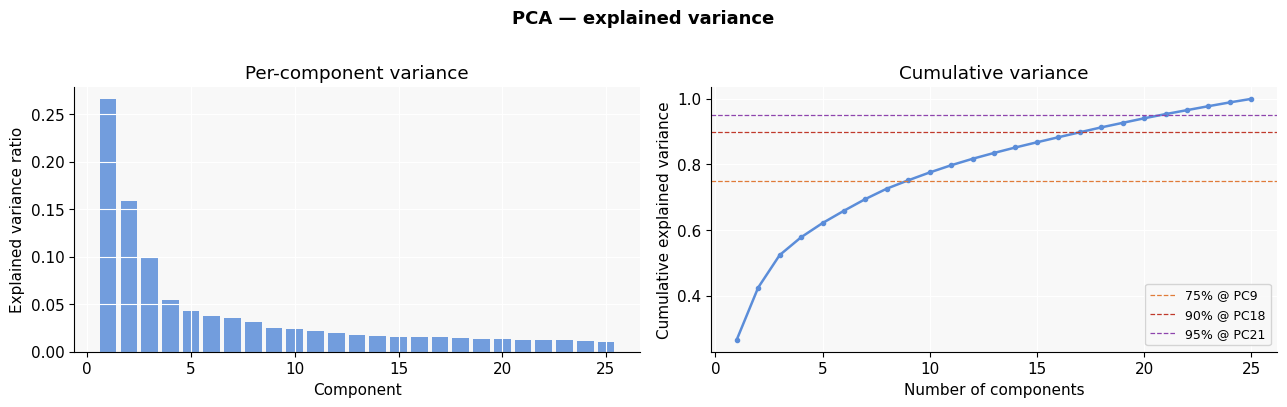

  Saved: plot_variance.png


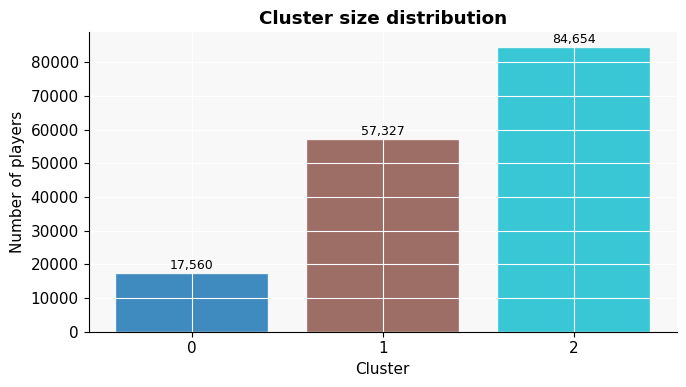

  Saved: plot_cluster_sizes.png


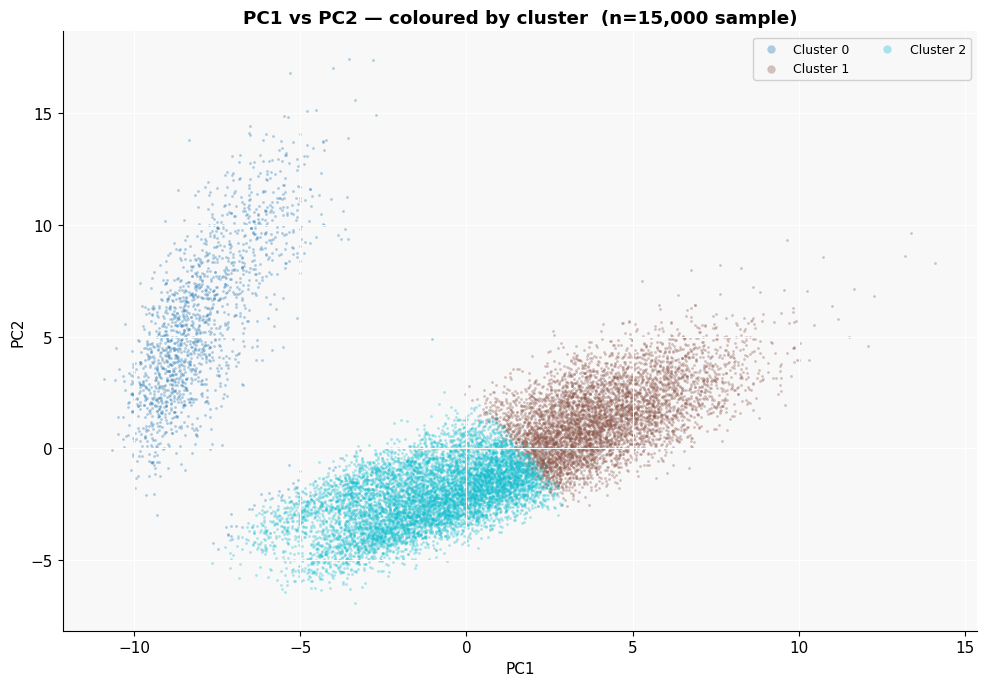

  Saved: plot_pca_clusters.png


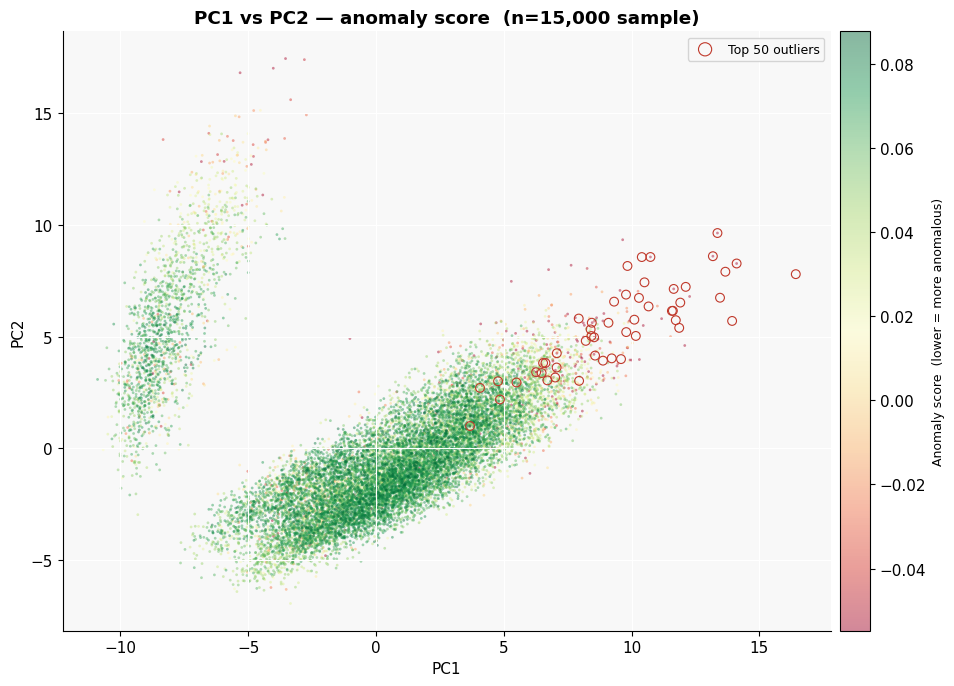

  Saved: plot_pca_anomaly.png


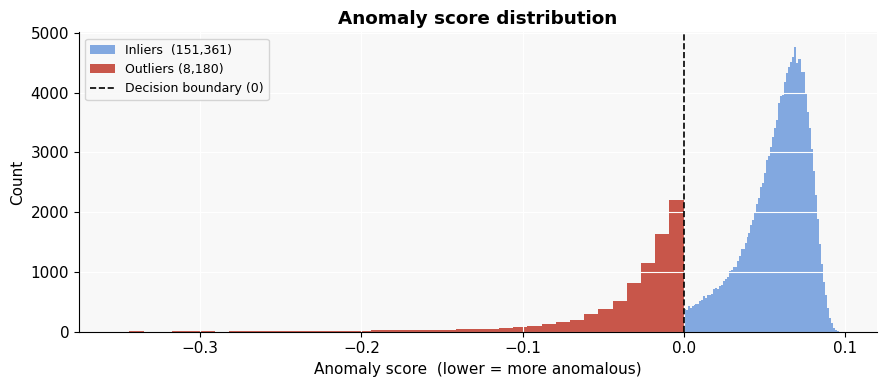

  Saved: plot_anomaly_dist.png

QUICK SUMMARY

PC1 range : -11.31 → 16.43
PC2 range : -7.07 → 21.06

Cluster breakdown:
  Cluster 0: 17,560 players ( 11.0%)  outliers: 1,411 (8.0%)
  Cluster 1: 57,327 players ( 35.9%)  outliers: 3,795 (6.6%)
  Cluster 2: 84,654 players ( 53.1%)  outliers: 2,974 (3.5%)

Top 10 most anomalous players:
              Name  cluster  anomaly_score
Zlatan Ibrahimovic        1      -0.352758
 Cristiano Ronaldo        1      -0.342717
       Carlos Ruiz        1      -0.342583
      Samuel Eto'o        1      -0.341075
      Robbie Keane        1      -0.340590
    Landon Donovan        1      -0.337059
     Didier Drogba        1      -0.332630
     Clint Dempsey        1      -0.330559
      Wayne Rooney        1      -0.330481
    Lukas Podolski        1      -0.318356


In [ ]:
"""
FM Pipeline — Results Visualisation
=====================================
Run this after fm_pipeline.py has produced its output files.
Loads from disk memmaps and fm_results.csv — no re-running the pipeline.

Plots
-----
  1. Explained variance curve
  2. Cluster size distribution
  3. PC1 vs PC2 — coloured by cluster
  4. PC1 vs PC2 — coloured by anomaly score (outliers highlighted)
  5. Anomaly score distribution
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from numpy.lib.format import open_memmap

# ── PATHS (match your pipeline Config) ────────────────────────────────────────
OUTPUT_DIR  = os.path.join(os.getcwd(), "data", "intermediate")
CSV_PATH    = os.path.join(os.getcwd(), "data", "intermediate", "preliminary_analysis.csv")

PCA_PATH    = os.path.join(OUTPUT_DIR, "fm_pca_coords.npy")
CLUSTER_PATH= os.path.join(OUTPUT_DIR, "fm_cluster_labels.npy")
SCORE_PATH  = os.path.join(OUTPUT_DIR, "fm_anomaly_scores.npy")
RESULTS_PATH= os.path.join(OUTPUT_DIR, "fm_results.csv")

# ── LOAD ──────────────────────────────────────────────────────────────────────
print("Loading outputs …")
results  = pd.read_csv(RESULTS_PATH)
pca_mm   = open_memmap(PCA_PATH,     mode="r", dtype=np.float32)
labels   = open_memmap(CLUSTER_PATH, mode="r", dtype=np.int32)
scores   = open_memmap(SCORE_PATH,   mode="r", dtype=np.float32)

# Pull PC1/PC2 from the memmap directly (same data as results CSV but exact)
pc1 = np.asarray(pca_mm[:, 0])
pc2 = np.asarray(pca_mm[:, 1])
cluster_labels  = np.asarray(labels)
anomaly_scores  = np.asarray(scores)
is_outlier      = anomaly_scores < 0

n_clusters = len(np.unique(cluster_labels))
print(f"  {len(results):,} players  |  {n_clusters} clusters  |  "
      f"{is_outlier.sum():,} outliers ({100*is_outlier.mean():.1f}%)")

# ── STYLE ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f8f8",
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
})

# Cluster colour palette — one distinct colour per k
cluster_cmap = plt.cm.get_cmap("tab10", n_clusters)
cluster_colours = cluster_cmap(cluster_labels)

# ── FIG 1 — Explained variance curve ──────────────────────────────────────────
# Recompute from a quick IncrementalPCA snapshot if available,
# otherwise reconstruct from PCA coords covariance (approximate).
# We'll load from the fitted pipeline via a tiny re-fit on the memmap
# — actually easier to just plot what we saved in the results printout.
# Here we reconstruct the explained variance from the PCA memmap itself.

ev_approx = np.load(os.path.join(OUTPUT_DIR, "fm_explained_variance.npy"))
cumev = np.cumsum(ev_approx)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("PCA — explained variance", fontsize=13, fontweight="bold", y=1.01)

ax = axes[0]
ax.bar(range(1, len(ev_approx)+1), ev_approx, color="#5b8dd9", alpha=0.85)
ax.set_xlabel("Component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("Per-component variance")

ax = axes[1]
ax.plot(range(1, len(cumev)+1), cumev, marker="o", markersize=3,
        color="#5b8dd9", linewidth=1.8)
for threshold, color, label in [(0.75, "#e07b39", "75%"),
                                  (0.90, "#c0392b", "90%"),
                                  (0.95, "#8e44ad", "95%")]:
    idx = int(np.searchsorted(cumev, threshold))
    if idx < len(cumev):
        ax.axhline(threshold, color=color, linestyle="--", linewidth=0.9,
                   label=f"{label} @ PC{idx+1}")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Cumulative variance")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_variance.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: plot_variance.png")

# ── FIG 2 — Cluster size distribution ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
unique_k, counts = np.unique(cluster_labels, return_counts=True)
bars = ax.bar(unique_k, counts,
              color=[cluster_cmap(k) for k in unique_k], alpha=0.85, edgecolor="white")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{count:,}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of players")
ax.set_title("Cluster size distribution", fontweight="bold")
ax.set_xticks(unique_k)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_cluster_sizes.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: plot_cluster_sizes.png")

# ── FIG 3 — PC1 vs PC2 coloured by cluster ────────────────────────────────────
# Subsample for scatter legibility (plotting 159k points is slow and muddy)
SCATTER_N = 15_000
rng       = np.random.RandomState(42)
idx       = rng.choice(len(pc1), size=min(SCATTER_N, len(pc1)), replace=False)

fig, ax = plt.subplots(figsize=(10, 7))
for k in unique_k:
    mask = cluster_labels[idx] == k
    ax.scatter(pc1[idx][mask], pc2[idx][mask],
               s=4, alpha=0.35, color=cluster_cmap(k), label=f"Cluster {k}", linewidths=0)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PC1 vs PC2 — coloured by cluster  (n={SCATTER_N:,} sample)",
             fontweight="bold")
legend = ax.legend(markerscale=3, fontsize=9, framealpha=0.9,
                   loc="upper right", ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_pca_clusters.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: plot_pca_clusters.png")

# ── FIG 4 — PC1 vs PC2 coloured by anomaly score (outliers on top) ────────────
# Sort so outliers are drawn last (on top of inliers)
sort_order  = np.argsort(anomaly_scores[idx])   # most anomalous drawn last
idx_sorted  = idx[sort_order]
score_sorted = anomaly_scores[idx_sorted]

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    pc1[idx_sorted], pc2[idx_sorted],
    c=score_sorted,
    cmap="RdYlGn",          # red = anomalous, green = normal
    s=4, alpha=0.45, linewidths=0,
    vmin=np.percentile(score_sorted, 1),
    vmax=np.percentile(score_sorted, 99),
)
cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("Anomaly score  (lower = more anomalous)", fontsize=9)

# Ring the top-50 outliers with a marker so they're easy to spot
top50_idx = np.argsort(anomaly_scores)[:50]
ax.scatter(pc1[top50_idx], pc2[top50_idx],
           s=40, facecolors="none", edgecolors="#c0392b",
           linewidths=0.8, label="Top 50 outliers", zorder=5)
ax.legend(fontsize=9, markerscale=1.5)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PC1 vs PC2 — anomaly score  (n={SCATTER_N:,} sample)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_pca_anomaly.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: plot_pca_anomaly.png")

# ── FIG 5 — Anomaly score distribution ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(anomaly_scores[~is_outlier], bins=80, color="#5b8dd9",
        alpha=0.75, label=f"Inliers  ({(~is_outlier).sum():,})")
ax.hist(anomaly_scores[is_outlier],  bins=40, color="#c0392b",
        alpha=0.85, label=f"Outliers ({is_outlier.sum():,})")
ax.axvline(0, color="black", linewidth=1.2, linestyle="--", label="Decision boundary (0)")
ax.set_xlabel("Anomaly score  (lower = more anomalous)")
ax.set_ylabel("Count")
ax.set_title("Anomaly score distribution", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot_anomaly_dist.png"), dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: plot_anomaly_dist.png")

# ── QUICK TEXT SUMMARY ─────────────────────────────────────────────────────────
print("\n" + "="*60)
print("QUICK SUMMARY")
print("="*60)
print(f"\nPC1 range : {pc1.min():.2f} → {pc1.max():.2f}")
print(f"PC2 range : {pc2.min():.2f} → {pc2.max():.2f}")
print(f"\nCluster breakdown:")
for k, cnt in zip(unique_k, counts):
    pct = 100 * cnt / len(results)
    out_in_cluster = is_outlier[cluster_labels == k].sum()
    print(f"  Cluster {k}: {cnt:6,} players ({pct:5.1f}%)  "
          f"outliers: {out_in_cluster:,} ({100*out_in_cluster/cnt:.1f}%)")

print(f"\nTop 10 most anomalous players:")
top10 = results.nsmallest(10, "anomaly_score")[["Name","cluster","anomaly_score"]]
print(top10.to_string(index=False))

In [1]:
"""
FM Dataset — Batched Unsupervised ML Pipeline  (v2)
====================================================
Changes from v1
---------------
  - k_range lowered to 2-7 (data shows ~2 natural clusters)
  - DBSCAN added alongside KMeans — better for the crescent/banana shape
    visible in the PCA scatter; doesn't require choosing k
  - contamination dropped from 0.05 → 0.01 (v1 was flagging elite players
    as "anomalous"; they are extreme but not erroneous)
  - n_components stays at 50 (variance plot confirmed 95% at PC21, so 50
    is already capturing almost everything)

PCA / SVD note
--------------
  IncrementalPCA uses truncated SVD internally — the PCA coordinate memmap
  IS the SVD-reduced representation.  PC1/PC2 is only used for plotting.
  The full n_components space is what goes into clustering and anomaly
  detection.  No separate SVD step is needed.

⚠️  Run this cell before any other numpy/sklearn imports (thread caps).
"""

import os, warnings

_N_CPU = "2"
for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
             "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_var, _N_CPU)

import gc, math, time
from contextlib import contextmanager
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
from numpy.lib.format import open_memmap
from sklearn.decomposition import IncrementalPCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import MiniBatchKMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from threadpoolctl import threadpool_limits as _tpl
    def _cpu_limit(n): return _tpl(limits=n)
except ImportError:
    @contextmanager
    def _cpu_limit(n): yield


# ── CONFIG ────────────────────────────────────────────────────────────────────

@dataclass
class Config:
    csv_path:   str = os.path.join(os.getcwd(), "data", "intermediate", "preliminary_analysis.csv")
    output_dir: str = os.path.join(os.getcwd(), "data", "intermediate")

    id_cols:   list = field(default_factory=lambda: ["Name"])
    drop_cols: list = field(default_factory=lambda: ["NationID"])

    # PCA — 50 covers ~95% variance per the explained-variance plot
    n_components: int = 50

    # KMeans — lowered: data shows ~2 natural clusters (GK arm + outfield mass)
    k_range:       range = field(default_factory=lambda: range(2, 8))
    kmeans_n_init: int   = 3

    # DBSCAN — operates in PCA space on a subsample (full 159k is slow)
    # eps: neighbourhood radius in PCA space; start at 1.5–2.5 and adjust
    #      based on the silhouette / cluster count it produces
    # min_samples: minimum points to form a core; ~0.1–0.5% of sample size
    dbscan_eps:         float = 2.0
    dbscan_min_samples: int   = 30
    dbscan_sample_n:    int   = 20_000   # subsample size for DBSCAN fit+predict

    # Anomaly detection
    # Lowered from 0.05: v1 was flagging elite players (Ronaldo, Zlatan etc.)
    # as anomalous — they are extreme but not erroneous.  0.01 targets only
    # the genuinely unusual records.
    contamination:        float = 0.01
    iforest_fit_rows:     int   = 20_000
    iforest_n_estimators: int   = 100

    # Silhouette subsample
    silhouette_n_rows: int = 2_000

    # Memory — peak ≈ 4× raw float64 chunk (sklearn upcasts internally)
    target_ram_mb: int = 48
    n_cpu:         int = 2


CFG = Config()


# ── HELPERS ───────────────────────────────────────────────────────────────────

def _batch_size(n_cols: int, cfg: Config) -> int:
    bytes_per_row = n_cols * 8
    batch = int((cfg.target_ram_mb * 1024 ** 2) / (bytes_per_row * 4.0))
    batch = max(batch, cfg.n_components + 1, 500)
    return int(math.ceil(batch / 500) * 500)

def _feature_cols(cfg: Config) -> list[str]:
    exclude = set(cfg.id_cols) | set(cfg.drop_cols)
    preview = pd.read_csv(cfg.csv_path, nrows=100, low_memory=False)
    cols = [c for c in preview.columns
            if c not in exclude and pd.api.types.is_numeric_dtype(preview[c])]
    skipped = [c for c in preview.columns if c not in exclude and c not in cols]
    if skipped:
        warnings.warn(f"Skipping non-numeric columns: {skipped}")
    return cols

def _count_rows(cfg: Config) -> int:
    return pd.read_csv(cfg.csv_path, usecols=[cfg.id_cols[0]], low_memory=False).shape[0]

def _csv_chunks(cfg: Config, feature_cols: list[str], batch_size: int):
    reader = pd.read_csv(cfg.csv_path, usecols=feature_cols,
                         chunksize=batch_size, low_memory=False)
    for i, chunk in enumerate(reader):
        yield i, chunk.to_numpy(dtype=np.float32, copy=False)

def _array_chunks(arr: np.ndarray, batch_size: int):
    for start in range(0, len(arr), batch_size):
        stop = min(start + batch_size, len(arr))
        yield start, stop, arr[start:stop]

def _safe_silhouette(coords: np.ndarray, labels: np.ndarray) -> float:
    unique = np.unique(labels[labels >= 0])   # exclude DBSCAN noise (-1)
    if len(unique) < 2 or len(unique) >= len(coords):
        return -1.0
    mask = labels >= 0
    if mask.sum() < 2:
        return -1.0
    return float(silhouette_score(coords[mask], labels[mask], metric="euclidean"))

def _progress(i, n, label="batch"):
    print(f"  {label} {i+1}/{n}", end="\r", flush=True)

def _clear():
    print(" " * 60, end="\r")


# ── PHASE 1a — StandardScaler ─────────────────────────────────────────────────

def phase1a_fit_scaler(cfg, feature_cols, batch_size, n_batches) -> StandardScaler:
    print("Phase 1a — StandardScaler.partial_fit (CSV pass 1) …")
    scaler = StandardScaler()
    with _cpu_limit(cfg.n_cpu):
        for i, batch in _csv_chunks(cfg, feature_cols, batch_size):
            scaler.partial_fit(batch)
            _progress(i, n_batches)
    _clear()
    print("  Scaler fitted.\n")
    return scaler


# ── PHASE 1b — IncrementalPCA ─────────────────────────────────────────────────

def phase1b_fit_pca(cfg, scaler, feature_cols, batch_size, n_batches) -> IncrementalPCA:
    print("Phase 1b — IncrementalPCA.partial_fit (CSV pass 2) …")
    pca = IncrementalPCA(n_components=cfg.n_components, batch_size=batch_size)
    with _cpu_limit(cfg.n_cpu):
        for i, batch in _csv_chunks(cfg, feature_cols, batch_size):
            pca.partial_fit(scaler.transform(batch))
            _progress(i, n_batches)
    _clear()

    ev    = pca.explained_variance_ratio_
    cumev = np.cumsum(ev)

    print("  Explained variance per component:")
    for k, (e, c) in enumerate(zip(ev, cumev), 1):
        bar  = "█" * int(e * 100)
        mark = " ← 90%" if c - e < 0.90 <= c else (
               " ← 95%" if c - e < 0.95 <= c else "")
        print(f"    PC{k:02d}  {e:.3f}  cum {c:.3f}  {bar}{mark}")

    t90 = int(np.searchsorted(cumev, 0.90)) + 1
    t95 = int(np.searchsorted(cumev, 0.95)) + 1
    print(f"\n  → {t90} components for 90% | {t95} for 95% | "
          f"PC{cfg.n_components:02d} total: {cumev[-1]:.3f}\n")

    np.save(os.path.join(cfg.output_dir, "fm_explained_variance.npy"), ev)
    return pca


# ── PHASE 2 — transform → PCA memmap ─────────────────────────────────────────

def phase2_transform(cfg, scaler, pca, feature_cols, n_rows, batch_size, n_batches):
    print("Phase 2 — transforming to PCA space (CSV pass 3, writing to disk) …")
    pipe     = Pipeline([("scaler", scaler), ("pca", pca)])
    pca_path = os.path.join(cfg.output_dir, "fm_pca_coords.npy")
    pca_mm   = open_memmap(pca_path, mode="w+", dtype=np.float32,
                           shape=(n_rows, cfg.n_components))
    cursor = 0
    with _cpu_limit(cfg.n_cpu):
        for i, batch in _csv_chunks(cfg, feature_cols, batch_size):
            out = pipe.transform(batch).astype(np.float32, copy=False)
            pca_mm[cursor:cursor+len(out)] = out
            cursor += len(out)
            _progress(i, n_batches)
    pca_mm.flush()
    _clear()
    print(f"  PCA memmap shape: {pca_mm.shape}  →  {pca_path}\n")
    del pipe, scaler, pca
    gc.collect()
    return pca_mm


# ── PHASE 3 — KMeans sweep ────────────────────────────────────────────────────

def phase3_kmeans(cfg, pca_mm, batch_size, n_batches) -> np.ndarray:
    print("Phase 3 — MiniBatchKMeans sweep …")
    n_rows  = len(pca_mm)
    rng     = np.random.RandomState(42)
    sil_idx = np.sort(rng.choice(n_rows, size=min(cfg.silhouette_n_rows, n_rows), replace=False))
    sil_buf = np.asarray(pca_mm[sil_idx], dtype=np.float32)

    best_k, best_score, best_km = list(cfg.k_range)[0], float("-inf"), None

    for k in cfg.k_range:
        km = MiniBatchKMeans(n_clusters=k, n_init=cfg.kmeans_n_init,
                             batch_size=max(batch_size, 1024), random_state=42)
        with _cpu_limit(cfg.n_cpu):
            for _, _, batch in _array_chunks(pca_mm, batch_size):
                km.partial_fit(batch)

        sil    = _safe_silhouette(sil_buf, km.predict(sil_buf))
        marker = "  ← best" if sil > best_score else ""
        print(f"    k={k:2d}  silhouette={sil:.4f}{marker}")
        if sil > best_score:
            best_score, best_k, best_km = sil, k, km

    print(f"  Best k = {best_k}  (silhouette = {best_score:.4f})\n")

    label_path = os.path.join(cfg.output_dir, "fm_cluster_labels.npy")
    label_mm   = open_memmap(label_path, mode="w+", dtype=np.int32, shape=(n_rows,))
    with _cpu_limit(cfg.n_cpu):
        for start, stop, batch in _array_chunks(pca_mm, batch_size):
            label_mm[start:stop] = best_km.predict(batch).astype(np.int32, copy=False)
    label_mm.flush()
    print(f"  KMeans labels  →  {label_path}\n")

    labels = np.asarray(label_mm, dtype=np.int32)
    del best_km, km, sil_buf, label_mm
    gc.collect()
    return labels


# ── PHASE 3b — DBSCAN (subsample) ─────────────────────────────────────────────

def phase3b_dbscan(cfg, pca_mm) -> np.ndarray:
    """
    DBSCAN on a subsample of the PCA space.
    Better than KMeans for the crescent/banana shaped manifold in the data.

    Label -1 = noise (points DBSCAN couldn't assign to any cluster).
    These are worth inspecting separately — they may overlap with anomalies.

    Tuning guide:
      eps (neighbourhood radius):
        Too small → almost everything is noise (-1)
        Too large → everything merges into one cluster
        Start at 1.5–2.5 for standardised PCA space; adjust based on output.
      min_samples:
        Higher → stricter core points, more noise
        Lower  → more permissive, fewer noise points
    """
    print("Phase 3b — DBSCAN (subsample) …")
    n_rows = len(pca_mm)
    rng    = np.random.RandomState(42)
    n_fit  = min(cfg.dbscan_sample_n, n_rows)
    idx    = np.sort(rng.choice(n_rows, size=n_fit, replace=False))
    sample = np.asarray(pca_mm[idx], dtype=np.float32)

    db = DBSCAN(eps=cfg.dbscan_eps, min_samples=cfg.dbscan_min_samples,
                n_jobs=cfg.n_cpu, metric="euclidean")
    with _cpu_limit(cfg.n_cpu):
        db_labels = db.fit_predict(sample)

    n_clusters = len(set(db_labels) - {-1})
    n_noise    = (db_labels == -1).sum()
    sil        = _safe_silhouette(sample, db_labels)
    print(f"  eps={cfg.dbscan_eps}  min_samples={cfg.dbscan_min_samples}")
    print(f"  Clusters found : {n_clusters}")
    print(f"  Noise points   : {n_noise} ({100*n_noise/n_fit:.1f}% of sample)")
    print(f"  Silhouette     : {sil:.4f}")

    # Cluster size breakdown
    for lbl in sorted(set(db_labels)):
        name = f"Cluster {lbl}" if lbl >= 0 else "Noise"
        cnt  = (db_labels == lbl).sum()
        print(f"    {name}: {cnt:,} ({100*cnt/n_fit:.1f}%)")

    # Save subsample labels (not full dataset — DBSCAN doesn't scale to 159k)
    db_path = os.path.join(cfg.output_dir, "fm_dbscan_sample_labels.npy")
    np.save(db_path, db_labels)
    idx_path = os.path.join(cfg.output_dir, "fm_dbscan_sample_idx.npy")
    np.save(idx_path, idx)
    print(f"  DBSCAN labels  →  {db_path}\n")

    del sample
    gc.collect()
    return db_labels, idx


# ── PHASE 4 — IsolationForest ─────────────────────────────────────────────────

def phase4_anomaly(cfg, pca_mm, batch_size, n_batches) -> np.ndarray:
    print("Phase 4 — IsolationForest anomaly scoring …")
    n_rows  = len(pca_mm)
    rng     = np.random.RandomState(42)
    fit_n   = min(cfg.iforest_fit_rows, n_rows)
    fit_idx = np.sort(rng.choice(n_rows, size=fit_n, replace=False))
    fit_buf = np.asarray(pca_mm[fit_idx], dtype=np.float32)

    iso = IsolationForest(n_estimators=cfg.iforest_n_estimators,
                          contamination=cfg.contamination,
                          max_samples=min(4096, fit_n),
                          random_state=42, n_jobs=cfg.n_cpu)
    print(f"  Fitting on {fit_n:,} rows  (contamination={cfg.contamination}) …")
    with _cpu_limit(cfg.n_cpu):
        iso.fit(fit_buf)
    del fit_buf
    gc.collect()

    score_path = os.path.join(cfg.output_dir, "fm_anomaly_scores.npy")
    score_mm   = open_memmap(score_path, mode="w+", dtype=np.float32, shape=(n_rows,))
    with _cpu_limit(cfg.n_cpu):
        for i, (start, stop, batch) in enumerate(_array_chunks(pca_mm, batch_size)):
            score_mm[start:stop] = iso.decision_function(batch).astype(np.float32, copy=False)
            _progress(i, n_batches)
    score_mm.flush()
    _clear()

    scores     = np.asarray(score_mm, dtype=np.float32)
    n_outliers = int((scores < 0).sum())
    print(f"  Flagged outliers: {n_outliers:,} ({100*n_outliers/n_rows:.1f}%)")
    print(f"  Anomaly scores  →  {score_path}\n")

    del iso, score_mm
    gc.collect()
    return scores


# ── PHASE 5 — results ─────────────────────────────────────────────────────────

def phase5_results(cfg, pca_mm, cluster_labels, anomaly_scores) -> pd.DataFrame:
    print("Phase 5 — assembling results …")
    names = pd.read_csv(cfg.csv_path, usecols=[cfg.id_cols[0]], low_memory=False)

    results = pd.DataFrame({
        "Name":          names[cfg.id_cols[0]].values,
        "cluster":       cluster_labels,
        "anomaly_score": anomaly_scores,
        "is_outlier":    anomaly_scores < 0,
        "PC1":           np.asarray(pca_mm[:, 0], dtype=np.float32),
        "PC2":           np.asarray(pca_mm[:, 1], dtype=np.float32),
    })

    print("  Cluster distribution:")
    for k, grp in results.groupby("cluster"):
        out = grp["is_outlier"].sum()
        print(f"    Cluster {k}: {len(grp):6,} players  "
              f"outliers: {out:,} ({100*out/len(grp):.1f}%)")

    print("\n  Top 10 most anomalous:")
    top = results.nsmallest(10, "anomaly_score")[["Name","cluster","anomaly_score"]]
    print(top.to_string(index=False))

    out_path = os.path.join(cfg.output_dir, "fm_results.csv")
    results.to_csv(out_path, index=False)
    print(f"\n  Results CSV  →  {out_path}\n")
    return results


# ── ENTRY POINT ───────────────────────────────────────────────────────────────

def run(cfg: Config = CFG) -> pd.DataFrame:
    t0 = time.time()
    os.makedirs(cfg.output_dir, exist_ok=True)

    print("=" * 70)
    print("FM UNSUPERVISED PIPELINE  v2")
    print("=" * 70)

    feature_cols = _feature_cols(cfg)
    n_rows       = _count_rows(cfg)
    batch_size   = _batch_size(len(feature_cols), cfg)
    n_batches    = math.ceil(n_rows / batch_size)

    print(f"  Rows            : {n_rows:,}")
    print(f"  Features        : {len(feature_cols)}")
    print(f"  Batch size      : {batch_size:,} rows  ({n_batches} batches)")
    print(f"  Target RAM/batch: {cfg.target_ram_mb} MB  (peak ≈ {cfg.target_ram_mb*4} MB)")
    print(f"  CPU threads     : {cfg.n_cpu}\n")

    scaler = phase1a_fit_scaler(cfg, feature_cols, batch_size, n_batches)
    pca    = phase1b_fit_pca(cfg, scaler, feature_cols, batch_size, n_batches)
    pca_mm = phase2_transform(cfg, scaler, pca, feature_cols, n_rows, batch_size, n_batches)

    cluster_labels       = phase3_kmeans(cfg, pca_mm, batch_size, n_batches)
    db_labels, db_idx    = phase3b_dbscan(cfg, pca_mm)
    anomaly_scores       = phase4_anomaly(cfg, pca_mm, batch_size, n_batches)
    results              = phase5_results(cfg, pca_mm, cluster_labels, anomaly_scores)

    print(f"Total time: {time.time()-t0:.1f}s")
    print("=" * 70)
    return results, db_labels, db_idx


results, db_labels, db_idx = run()

FM UNSUPERVISED PIPELINE  v2
  Rows            : 159,541
  Features        : 84
  Batch size      : 19,000 rows  (9 batches)
  Target RAM/batch: 48 MB  (peak ≈ 192 MB)
  CPU threads     : 2

Phase 1a — StandardScaler.partial_fit (CSV pass 1) …
  Scaler fitted.                                            

Phase 1b — IncrementalPCA.partial_fit (CSV pass 2) …
  Explained variance per component:                         
    PC01  0.200  cum 0.200  ███████████████████
    PC02  0.119  cum 0.319  ███████████
    PC03  0.074  cum 0.393  ███████
    PC04  0.041  cum 0.434  ████
    PC05  0.033  cum 0.467  ███
    PC06  0.028  cum 0.495  ██
    PC07  0.027  cum 0.522  ██
    PC08  0.024  cum 0.546  ██
    PC09  0.019  cum 0.565  █
    PC10  0.018  cum 0.583  █
    PC11  0.017  cum 0.599  █
    PC12  0.015  cum 0.615  █
    PC13  0.014  cum 0.629  █
    PC14  0.013  cum 0.642  █
    PC15  0.012  cum 0.654  █
    PC16  0.012  cum 0.666  █
    PC17  0.012  cum 0.678  █
    PC18  0.011  cum 0.689  